## **Binary Search Tree**

In [38]:
class TreeNode:                 # as node in linked List
    def __init__(self, x):
        self.val = x
        self.left = None
        self.right = None

In [94]:
from graphviz import Digraph

def visualize_tree(tree):
    if tree is None: return 'Nothing in the tree!'
    def add_nodes_edges(tree, dot=None):
        # Create digraph object
        if dot is None:
            dot = Digraph()
            dot.attr('node', shape = 'circle')
            dot.node(name=str(tree), label=str(tree.val))
            
        for child in [tree.left, tree.right]:   # do for all children
            if child is not None:
                if child == tree.left: dot.attr('node', shape='circle', style='filled', color='lightblue')
                if child == tree.right: dot.attr('node', shape='doublecircle', style='filled', color='lightgreen')
                dot.node(name=str(child) ,label=str(child.val))
                dot.edge(str(tree), str(child))
                dot = add_nodes_edges(child,dot=dot) # recursive call
                
        
        return dot
    
    # Add nodes recursively and create a list of edges
    dot = add_nodes_edges(tree)
    
    # Visualize the graph
    display(dot)

In [95]:
# Print all nodes on the tree
# It is Pre-order Traversal          Root -->Left-->Right
def dfs(self):
    print(self.val)
    
    if self.left:
        self.left.dfs()
    if self.right:
        self.right.dfs()
        
TreeNode.dfs = dfs

In [96]:
# it is inorder traversal       Left-->Root --> Right
def dfs_inorder(self):
    if self.left:
        self.left.dfs_inorder()
        
    print(self.val)
    
    if self.right:
        self.right.dfs_inorder()
        
TreeNode.dfs_inorder = dfs_inorder

In [97]:
# it is postorder traversal    Left-->Right --> Root
def dfs_postorder(self):
    if self.left:
        self.left.dfs_postorder()
        
    if self.right:
        self.right.dfs_postorder()
        
    print(self.val)
    

TreeNode.dfs_postorder = dfs_postorder

# Binary Search Tree

In [98]:
class BST(TreeNode):
    def __init__(self, val, parent = None):
        super().__init__(val)
        self.parent = parent
        
        
    def insert(self, val):
        if val < self.val:       # insert into left
            if self.left is None:
                new_node = BST(val, parent=self)
                self.left = new_node
            else:
                self.left.insert(val)
            
        else:    # greater
            if self.right is None:
                self.right = BST(val, parent=self)
            else:
                self.right.insert(val)

In [99]:
b = BST(20)
print(b.val)

20


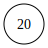

In [100]:
visualize_tree(b)

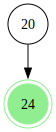

In [101]:
b.insert(24)
visualize_tree(b)

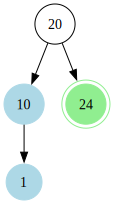

In [102]:
b.insert(10)
b.insert(1)
visualize_tree(b)

In [103]:
b.dfs_inorder()         # it will give you a accending order

1
10
20
24


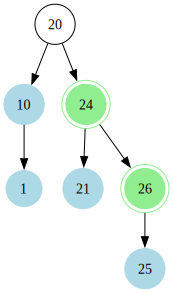

In [104]:
b.insert(21)
b.insert(26)
b.insert(25)
visualize_tree(b)

# **Deletion from the BST**

First, we'll need some helper functions. Let's discuss those first.

In [105]:
def find_root(self):
    """find the absolute root of the BST to which self belongs. Keep going up until you """
    
    temp = self
    while temp.parent is not None:
        temp = temp.parent
        
    return temp
    # keep going up untill no parent ..... return that.
    
BST.find_root = find_root

In [106]:
def find_min(self):
    """Find the minimum value starting from self.
       In BST, this is simple, keep going left untill left is left!"""
       
    min_node = self
    
    if self.left is not None:
        min_node = find_min(self.left)
        
    return min_node

BST.find_min = find_min

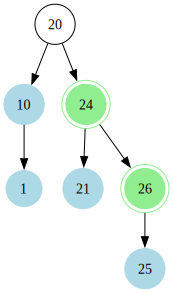

Min is:  21


In [107]:
visualize_tree(b)
print("Min is: ",b.right.find_min().val)

In [108]:
def set_for_parent(self, new_ref):
    """Disconnect self from parent and attach new_ref to parent in self's place."""
    
    if self.parent is None: return
    
    if self.parent.right == self:
        self.parent.right = new_ref
        
    if self.parent.left == self:
        self.parent.left = new_ref
        
BST.set_for_parent = set_for_parent

In [109]:
def replace_with_node(self, node):
    """Replace self with node (which is a child). Make sure to fix the parent of the node
       Assume we have no children other then node."""
       
    self.set_for_parent(node)       # connect new node to parent on poper location
    node.parent = self.parent       # set node's parent correctly
    # self.parent = None              # disconnect self from the parent(can be done by garbage collector)
    return node.find_root()         # find root again

BST.replace_with_node = replace_with_node

In [110]:
def delete(self,val):
    # first ... if we are alone, on the root and no children plus the value matches just return None
    if self.parent is None and self.left is None and self.val == val:
        return None
    
    # we are the node to be deleted
    if self.val == val:
        # check if we are leaf
        if self.right is None and self.left is None:
            self.set_for_parent(None)       # set in place of self a None
            return self.find_root()
        
         
        # check if we have just a left node 
        if self.right is None:
            return self.replace_with_node(self.left)
        
        # check if we have just a right node 
        if self.left is None:
            return self.replace_with_node(self.right)
        
        
        # now we have both children. Find the successor and replace "self" with it.
        # (Our succ is definitely in our right child and it can't have two children because left child will always be smaller.)
        successor = self.right.find_min()
        
        # copy successor's val here 
        self.val = successor.val
        
        
        return self.right.delete(successor.val)
        # ^ delete the successor node, which is in our right child BST.
        # ^ It's guaranteed that it's the simpler case since successor CANNOT have a left child
        
    # we were not the node to be deleted, go to children
    if val < self.val :
        if self.left:
            return self.left.delete(val)
        else:
            return self.find_root()     # nothing to delete
        
    else:
        if self.right is not None:
            return self.right.delete(val)
        else: 
            return self.find_root()
        
        
BST.delete = delete

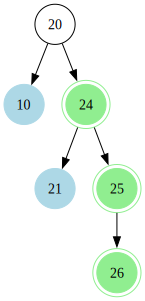

In [111]:
b = BST(20)
b.insert(24)
b.insert(21)
b.insert(10)
b.insert(25)
b.insert(26)
visualize_tree(b)

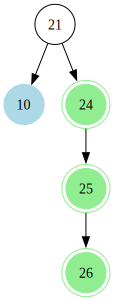

In [112]:
b = b.delete(20)
visualize_tree(b)

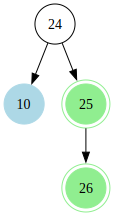

In [113]:
b = b.delete(21)
visualize_tree(b)

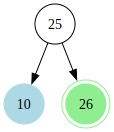

In [114]:
b = b.delete(24)
visualize_tree(b)

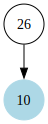

In [115]:
b = b.delete(25)
visualize_tree(b)

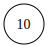

In [116]:
b = b.delete(26)
visualize_tree(b)

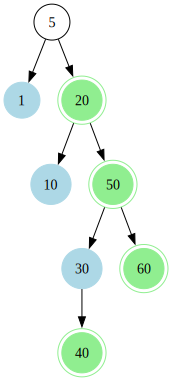

In [117]:
b = BST(5)
b.insert(1)
b.insert(20)
b.insert(10)
b.insert(50)
b.insert(30)
b.insert(40)
b.insert(60)
visualize_tree(b)

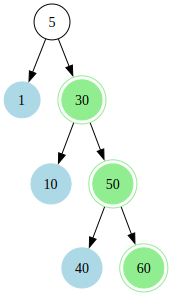

In [118]:
b = b.delete(20)
visualize_tree(b)

# **Issue with the BST - Balance**

In [119]:
l = [1, 2, 4, 9, 13, 21, 71, 82]

In [122]:
b = BST(l[0])
for i in l[1:]:
    b.insert(i)

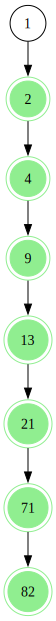

In [123]:
visualize_tree(b)

In [124]:
b.dfs_inorder()

1
2
4
9
13
21
71
82


This issue is resolved using advanced BSTs such as RB trees and AVL trees. Balance is achieved using the concept of rotation based on different on different rules.